# Bias–Variance Tradeoff & Model Evaluation Metrics

A hands-on notebook covering how we judge whether a machine learning model is good, and the two errors that pull every model in opposite directions.

**What this notebook covers**

1. Understanding **Bias** and **Variance** (underfitting vs overfitting)
2. **Mean Squared Error (MSE)** — what it is and how to compute it by hand
3. **R² Score** — the coefficient of determination, computed step by step
4. **In-class problems** — identify bias vs variance, and compute R²
5. **Lab** — frame 5 real problems as ML tasks, compute MSE for each, and plot bias–variance curves

**How to use this notebook**
- Run a code cell with **Shift + Enter**.
- The cells marked **📝 Notes** are blank for you — double-click to edit and write in your own words.
- Run cells **in order** from top to bottom (later cells reuse functions defined earlier).

In [1]:
# Setup — run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots show up inline and look consistent
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(suppress=True)
print("Libraries loaded \u2713")

Libraries loaded ✓


---
# Part 1 · Understanding Bias and Variance

Every prediction a model makes carries some error. We split that error into two useful ideas.

### Bias
**Bias** is error from a model being **too simple** to capture the real pattern in the data. A high-bias model makes strong, rigid assumptions and ends up *underfitting* — it does poorly even on the data it was trained on.

> Example: trying to fit a straight line through data that actually curves.

### Variance
**Variance** is error from a model being **too sensitive** to the specific training data. A high-variance model bends to fit every point, including random noise, and ends up *overfitting* — it looks great on training data but fails on new, unseen data.

> Example: a wiggly curve that passes through every training point exactly but predicts wildly between them.

### The Tradeoff
Making a model more complex **lowers bias but raises variance**. Making it simpler does the reverse. The goal is the **sweet spot** in the middle — low enough bias *and* low enough variance to generalize well.

### Diagnosing a model from its scores

| Training performance | Test performance | Diagnosis | Meaning |
| --- | --- | --- | --- |
| Poor | Poor | **High Bias** | Underfitting — model is too simple |
| Excellent | Poor | **High Variance** | Overfitting — model memorised the noise |
| Good | Good | **Balanced** | Low bias *and* low variance — generalises well |

The key signal is the **gap** between training and test performance:
- Small gap, both low → high bias
- Large gap (great train, weak test) → high variance
- Small gap, both high → balanced

> ### 📝 Notes
>
> _Double-click this cell to write your own notes here._
>
> -
> -
> -

---
# Part 2 · Mean Squared Error (MSE)

**MSE** measures how far predictions are from the actual values, on average. We square each error so that positive and negative errors don't cancel out, and so that larger mistakes are penalised more heavily.

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where:
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $n$ = number of data points

A **lower MSE means a better fit**. The lowest possible value is 0 (perfect predictions). Note that MSE is in *squared units* of the target.

In [2]:
# Compute MSE manually (no libraries doing the work for us)
def manual_mse(y_actual, y_predicted):
    y_actual = np.array(y_actual, dtype=float)
    y_predicted = np.array(y_predicted, dtype=float)
    n = len(y_actual)
    squared_errors = (y_actual - y_predicted) ** 2   # square each error
    return squared_errors.sum() / n                  # average them

# Quick test
print("MSE:", manual_mse([10, 15, 20], [11, 14, 22]))

MSE: 2.0


### Worked example

Let's compute the MSE for these five predictions and show every intermediate step in a table.

In [3]:
y_actual    = [10, 15, 20, 25, 30]
y_predicted = [12, 14, 18, 24, 32]

errors = np.array(y_actual) - np.array(y_predicted)

table = pd.DataFrame({
    "Actual (y)": y_actual,
    "Predicted (y_hat)": y_predicted,
    "Error (y - y_hat)": errors,
    "Squared Error": errors ** 2,
})
display(table)

print("Sum of Squared Errors :", (errors ** 2).sum())
print("Number of points (n)  :", len(y_actual))
print("MSE                   :", manual_mse(y_actual, y_predicted))

,Actual (y),Predicted (y_hat),Error (y - y_hat),Squared Error
0,10,12,-2,4
1,15,14,1,1
2,20,18,2,4
3,25,24,1,1
4,30,32,-2,4


Sum of Squared Errors : 14
Number of points (n)  : 5
MSE                   : 2.8


> ### 📝 Notes
>
> _Double-click this cell to write your own notes here._
>
> -
> -
> -

---
# Part 3 · R² Score (Coefficient of Determination)

MSE tells us the size of the error, but not whether that error is "big" relative to the data. **R²** fixes this by asking: *how much of the variation in the target did the model actually explain?*

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

| Term | Name | Formula | Meaning |
| --- | --- | --- | --- |
| $SS_{res}$ | Residual sum of squares | $\sum (y_i - \hat{y}_i)^2$ | Error the model still makes |
| $SS_{tot}$ | Total sum of squares | $\sum (y_i - \bar{y})^2$ | Total variation in the data |

**Reading R²:**
- $R^2 = 1$ → perfect predictions
- $R^2 = 0$ → the model is no better than just predicting the mean $\bar{y}$
- $R^2 < 0$ → the model is *worse* than predicting the mean

The closer R² is to **1**, the better the fit.

In [4]:
# Compute R-squared manually, step by step
def manual_r2(y_actual, y_predicted):
    y_actual = np.array(y_actual, dtype=float)
    y_predicted = np.array(y_predicted, dtype=float)

    y_mean = y_actual.mean()
    ss_res = ((y_actual - y_predicted) ** 2).sum()   # residual sum of squares
    ss_tot = ((y_actual - y_mean) ** 2).sum()         # total sum of squares
    return 1 - ss_res / ss_tot

### Worked example — step by step

Using the same five points, we'll build up $\bar{y}$, $SS_{res}$, and $SS_{tot}$ in tables before computing R².

In [5]:
y_actual    = [10, 15, 20, 25, 30]
y_predicted = [12, 14, 18, 24, 32]

# Step 1: mean of the actual values
y_mean = np.mean(y_actual)
print("Step 1 -> Mean of actual values (y_bar):", y_mean)

Step 1 -> Mean of actual values (y_bar): 20.0


In [6]:
# Step 2: SS_res = sum of squared residuals (actual - predicted)
residuals = np.array(y_actual) - np.array(y_predicted)

ss_res_table = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": y_predicted,
    "Residual": residuals,
    "Residual^2": residuals ** 2,
})
display(ss_res_table)

SS_res = (residuals ** 2).sum()
print("Step 2 -> SS_res =", SS_res)

,Actual,Predicted,Residual,Residual^2
0,10,12,-2,4
1,15,14,1,1
2,20,18,2,4
3,25,24,1,1
4,30,32,-2,4


Step 2 -> SS_res = 14


In [7]:
# Step 3: SS_tot = sum of squared deviations from the mean
deviations = np.array(y_actual) - y_mean

ss_tot_table = pd.DataFrame({
    "Actual": y_actual,
    "Mean": [y_mean] * len(y_actual),
    "Deviation": deviations,
    "Deviation^2": deviations ** 2,
})
display(ss_tot_table)

SS_tot = (deviations ** 2).sum()
print("Step 3 -> SS_tot =", SS_tot)

,Actual,Mean,Deviation,Deviation^2
0,10,20.0,-10.0,100.0
1,15,20.0,-5.0,25.0
2,20,20.0,0.0,0.0
3,25,20.0,5.0,25.0
4,30,20.0,10.0,100.0


Step 3 -> SS_tot = 250.0


In [8]:
# Step 4: put it together
r2 = 1 - SS_res / SS_tot
print("Step 4 -> R^2 = 1 - SS_res / SS_tot")
print(f"             = 1 - {SS_res}/{SS_tot}")
print(f"             = {r2:.3f}")

# confirm with our function
print("\nUsing manual_r2():", round(manual_r2(y_actual, y_predicted), 3))

Step 4 -> R^2 = 1 - SS_res / SS_tot
             = 1 - 14/250.0
             = 0.944

Using manual_r2(): 0.944


### Interpretation

- $R^2 = 0.944$
- The model explains **94.4%** of the variation in the target variable.
- The remaining **5.6%** is unexplained — due to prediction errors or factors the model doesn't capture.

| Metric | Value |
| --- | --- |
| Mean of actual values ($\bar{y}$) | 20 |
| $SS_{res}$ | 14 |
| $SS_{tot}$ | 250 |
| $R^2$ | **0.944 (94.4%)** |

> ### 📝 Notes
>
> _Double-click this cell to write your own notes here._
>
> -
> -
> -

---
# Part 4 · In-Class Problems

Work through these before looking at the solution cells.

## Problem 1 — Identify the issue: Bias or Variance?

For each model, decide whether it suffers from **High Bias (Underfitting)**, **High Variance (Overfitting)**, or **Neither (Balanced)**.

| Model | Training accuracy | Test accuracy | Description |
| --- | --- | --- | --- |
| **Model A** | 60% | 58% | Too simple; performs poorly on both training and test data. |
| **Model B** | 99% | 72% | Memorises the training data but does poorly on new data. |
| **Model C** | 94% | 92% | Performs well on both training and test data. |

**Reminder of the rule**

| Observation | Conclusion |
| --- | --- |
| Poor train **and** poor test | High Bias (Underfitting) |
| Excellent train **but** poor test | High Variance (Overfitting) |
| Good train **and** good test | Balanced |

> ### Your answers (Problem 1)
>
> _Fill these in before revealing the solution below._
>
> | Model | Your answer | Why? |
> | --- | --- | --- |
> | Model A |  |  |
> | Model B |  |  |
> | Model C |  |  |

<details>
<summary><b>Click to reveal the solution to Problem 1</b></summary>

| Model | Answer | Explanation |
| --- | --- | --- |
| **Model A** | **High Bias (Underfitting)** | Both scores are low and close together — the model can't even fit the training data because it is too simple. |
| **Model B** | **High Variance (Overfitting)** | Near-perfect on training but a big drop on test — it has learned the training data too closely, including the noise. |
| **Model C** | **Balanced (Low Bias, Low Variance)** | Both scores are high and close together — it has learned the real pattern and generalises to unseen data. |

</details>

## Problem 2 — Compute R² for these predictions

A model produced the following predictions. Compute its R² score **by hand**, then check with `manual_r2()`.

| Actual ($y$) | Predicted ($\hat{y}$) |
| ---: | ---: |
| 2 | 3 |
| 4 | 4 |
| 6 | 5 |
| 8 | 9 |
| 10 | 9 |

**Steps:** (1) find $\bar{y}$, (2) compute $SS_{res}$, (3) compute $SS_{tot}$, (4) apply the formula.

In [ ]:
# Problem 2 — your workspace
# Try computing y_mean, SS_res, and SS_tot yourself before running the solution cell.

y_actual    = [2, 4, 6, 8, 10]
y_predicted = [3, 4, 5, 9, 9]

# y_mean =
# SS_res =
# SS_tot =
# r2     =

> ### Your working (Problem 2)
>
> _Write each step here:_
>
> - $\bar{y} = $
> - $SS_{res} = $
> - $SS_{tot} = $
> - $R^2 = $

<details>
<summary><b>Click to reveal the solution to Problem 2</b></summary>

- $\bar{y} = \dfrac{2+4+6+8+10}{5} = 6$
- $SS_{res} = (2-3)^2+(4-4)^2+(6-5)^2+(8-9)^2+(10-9)^2 = 1+0+1+1+1 = 4$
- $SS_{tot} = (2-6)^2+(4-6)^2+(6-6)^2+(8-6)^2+(10-6)^2 = 16+4+0+4+16 = 40$
- $R^2 = 1 - \dfrac{4}{40} = 1 - 0.1 = \mathbf{0.90}$

The model explains **90%** of the variation in the target.

</details>

In [ ]:
# Problem 2 — solution check
y_actual    = [2, 4, 6, 8, 10]
y_predicted = [3, 4, 5, 9, 9]

y_mean = np.mean(y_actual)
SS_res = ((np.array(y_actual) - np.array(y_predicted)) ** 2).sum()
SS_tot = ((np.array(y_actual) - y_mean) ** 2).sum()

print("y_mean :", y_mean)
print("SS_res :", SS_res)
print("SS_tot :", SS_tot)
print("R^2    :", round(manual_r2(y_actual, y_predicted), 3))

> ### 📝 Notes
>
> _Double-click this cell to write your own notes here._
>
> -
> -
> -

---
# Part 5 · Lab / Coding

Three connected tasks:
1. Frame **5 real-world problems** as machine learning tasks.
2. Compute the **MSE** for each (using the `manual_mse` function from Part 2).
3. Plot **bias–variance curves** to *see* underfitting and overfitting.

## Lab Task 1 — Frame 5 real problems as ML tasks

For every problem we identify: the **input features** ($X$) the model learns from, the **target** ($y$) it predicts, and the **task type**. All five below predict a continuous number, so they are **regression** tasks (as opposed to classification, which predicts a category).

| # | Real-world problem | Input features (X) | Target (y) | Task type |
| --- | --- | --- | --- | --- |
| 1 | Predict the selling price of a house | area (sq ft), bedrooms, location score, age | price (₹ lakhs) | Regression |
| 2 | Predict a student's final exam score | hours studied, attendance %, past grades | exam score (0–100) | Regression |
| 3 | Predict a household's monthly electricity bill | units consumed, no. of appliances, season | bill amount (₹) | Regression |
| 4 | Predict crop yield for a farm plot | rainfall (mm), fertiliser (kg), temperature | yield (tonnes/hectare) | Regression |
| 5 | Predict food delivery time | distance (km), traffic level, prep time | delivery time (minutes) | Regression |

> **Why regression?** The target in each case is a number on a continuous scale. If instead we predicted *categories* — e.g. "spam vs not spam", or "pass vs fail" — it would be a **classification** task.

> ### Notes — try framing one of your own
>
> _Pick any real-world prediction you can think of and fill in the row:_
>
> | Problem | Input features (X) | Target (y) | Task type |
> | --- | --- | --- | --- |
> |  |  |  |  |

## Lab Task 2 — Compute MSE manually for each problem

Below, each problem has a small set of **actual** outcomes and the model's **predicted** values. We compute the MSE for all five in one pass.

In [ ]:
# Actual vs predicted values for each of the 5 problems
problems = {
    "House Price (\u20b9 lakhs)":   ([50, 75, 60, 90, 120], [55, 70, 65, 85, 110]),
    "Exam Score (0-100)":       ([88, 72, 95, 60, 80],  [85, 75, 90, 65, 78]),
    "Electricity Bill (\u20b9)":     ([1200, 1500, 900, 2000, 1700], [1100, 1600, 1000, 1900, 1750]),
    "Crop Yield (t/ha)":        ([3.2, 2.8, 4.0, 3.5, 2.5], [3.0, 3.0, 3.8, 3.6, 2.7]),
    "Delivery Time (min)":      ([30, 45, 25, 50, 40],  [28, 48, 27, 46, 42]),
}

results = []
for name, (actual, predicted) in problems.items():
    results.append({"Problem": name, "MSE": round(manual_mse(actual, predicted), 4)})

mse_summary = pd.DataFrame(results)
display(mse_summary)

**Notice** how the MSE values are wildly different in size (the electricity bill MSE is in the thousands, the crop-yield MSE is a fraction). That's because **MSE depends on the units of the target**, so you can't directly compare MSE across different problems. This is exactly why a *unitless* score like R² is useful when comparing models on different scales.

In [ ]:
# Optional: see one problem broken down in detail (change the key to inspect others)
name = "Delivery Time (min)"
actual, predicted = problems[name]

errors = np.array(actual) - np.array(predicted)
detail = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted,
    "Error": errors,
    "Squared Error": errors ** 2,
})
display(detail)
print(f"{name}  ->  MSE = {manual_mse(actual, predicted)}")

> ### 📝 Notes
>
> _Double-click this cell to write your own notes here._
>
> -
> -
> -

## Lab Task 3 — Plot the bias–variance curves

Now we'll *see* the tradeoff. We create some data that follows a curved pattern plus a bit of random noise, then fit polynomial models of **increasing complexity** (degree 1, 2, 3, …). For each model we measure the error on the **training** set and on a held-out **test** set.

What we expect to see:
- **Training error** keeps dropping as complexity rises (the model fits the training points ever more tightly).
- **Test error** drops at first, hits a minimum (the sweet spot), then rises again as the model starts memorising noise.

In [13]:
# 1) Create synthetic data: a curved 'true' pattern + random noise
rng = np.random.RandomState(1)          # fixed seed so everyone sees the same plot

def true_function(x):
    return np.cos(1.5 * np.pi * x)

n_samples = 40
X = np.sort(rng.rand(n_samples))
y = true_function(X) + rng.randn(n_samples) * 0.3

# 2) Split into training and test sets (65% train / 35% test)
idx = rng.permutation(n_samples)
split = int(0.65 * n_samples)
train_idx, test_idx = idx[:split], idx[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Training points: {len(X_train)}   Test points: {len(X_test)}")

Training points: 26   Test points: 14


In [14]:
# 3) Fit polynomials of increasing degree and record train/test MSE
degrees = range(1, 14)
train_errors, test_errors = [], []

for d in degrees:
    coeffs = np.polyfit(X_train, y_train, d)          # fit a degree-d polynomial
    y_train_pred = np.polyval(coeffs, X_train)
    y_test_pred  = np.polyval(coeffs, X_test)
    train_errors.append(manual_mse(y_train, y_train_pred))
    test_errors.append(manual_mse(y_test,  y_test_pred))

best_degree = list(degrees)[int(np.argmin(test_errors))]
print("Lowest test error at polynomial degree:", best_degree)

Lowest test error at polynomial degree: 5


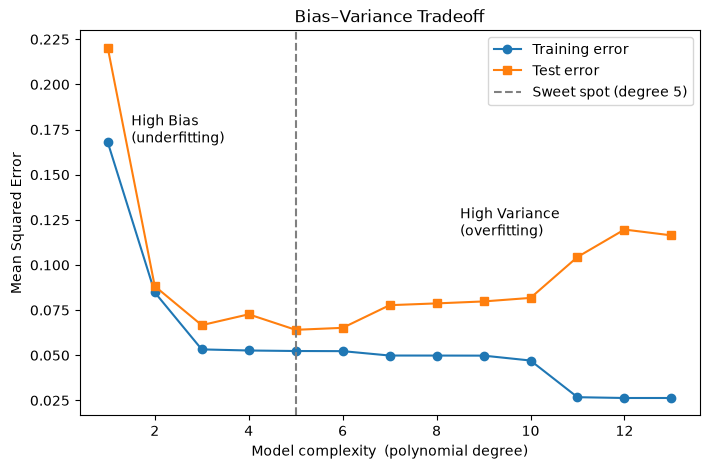

In [11]:
# 4) Plot the bias-variance curve
plt.figure()
plt.plot(list(degrees), train_errors, "o-", label="Training error")
plt.plot(list(degrees), test_errors,  "s-", label="Test error")
plt.axvline(best_degree, linestyle="--", color="gray", label=f"Sweet spot (degree {best_degree})")

plt.annotate("High Bias\n(underfitting)", xy=(1, train_errors[0]),
             xytext=(1.5, train_errors[0]), fontsize=10)
plt.annotate("High Variance\n(overfitting)", xy=(degrees[-1], test_errors[-1]),
             xytext=(8.5, test_errors[-1]), fontsize=10)

plt.xlabel("Model complexity  (polynomial degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias\u2013Variance Tradeoff")
plt.legend()
plt.show()

**Reading the curve**
- On the **left** (degree 1): both errors are high → the straight line is too simple → **high bias / underfitting**.
- In the **middle** (around the dashed line): test error is at its minimum → **balanced**, the best choice.
- On the **right** (high degree): training error keeps falling while test error climbs → **high variance / overfitting**.

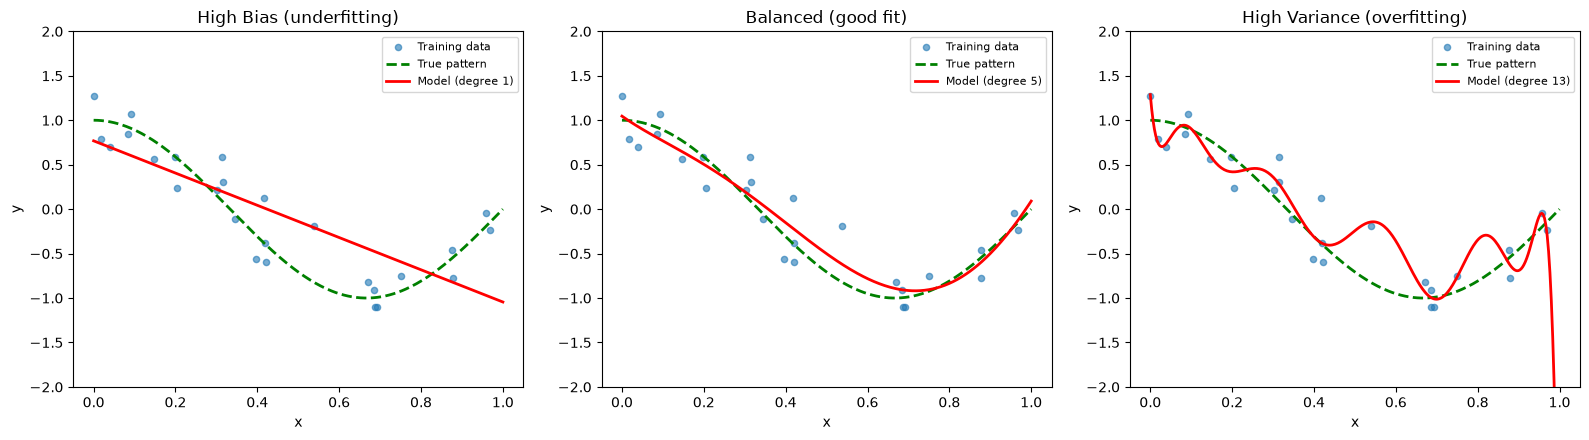

In [12]:
# 5) See the three regimes as actual model fits
xx = np.linspace(0, 1, 300)
fits = [(1, "High Bias (underfitting)"),
        (best_degree, "Balanced (good fit)"),
        (13, "High Variance (overfitting)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (d, title) in zip(axes, fits):
    coeffs = np.polyfit(X_train, y_train, d)
    ax.scatter(X_train, y_train, s=20, alpha=0.6, label="Training data")
    ax.plot(xx, true_function(xx), "g--", linewidth=2, label="True pattern")
    ax.plot(xx, np.polyval(coeffs, xx), "r-", linewidth=2, label=f"Model (degree {d})")
    ax.set_ylim(-2, 2)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Compare the three panels:
- **Left** — the model (red) is a straight line that ignores the curve in the green true pattern. It misses the shape entirely.
- **Middle** — the red model closely tracks the green true pattern without chasing individual points. This generalises best.
- **Right** — the red model whips up and down to pass near every training point, drifting far from the true pattern between them. It will predict poorly on new data.

> ### 📝 Notes
>
> _Double-click this cell to write your own notes here._
>
> -
> -
> -

---
# Summary — Key Takeaways

| Concept | One-line summary |
| --- | --- |
| **Bias** | Error from a model that's too simple → **underfitting** (poor on train *and* test). |
| **Variance** | Error from a model that's too sensitive to training data → **overfitting** (great on train, poor on test). |
| **The tradeoff** | More complexity lowers bias but raises variance; the best model sits in between. |
| **MSE** | Average of squared errors, $\frac{1}{n}\sum (y-\hat{y})^2$. Lower is better; depends on the target's units. |
| **R²** | Fraction of variation explained, $1 - SS_{res}/SS_{tot}$. Closer to 1 is better; unitless, so comparable across problems. |
| **Diagnosis** | Compare train vs test: both low → bias; big gap → variance; both high → balanced. |

**Functions built in this notebook**
- `manual_mse(y_actual, y_predicted)` — Mean Squared Error from scratch
- `manual_r2(y_actual, y_predicted)` — R² score from scratch